# Google Colab Lab Assignment - Image Classification using CNN and Transfer Learning

**Course Name:** Generative AI Lab

**Lab Title:** Practical No-01: Image Classification using CNN and Transfer Learning

**Student Name:** *Vineet Kaldate*

**Student ID:** *202401110074*

**Date of Submission:** *15/08/26*

**Group Members:** *Rameshwar Sanap, Sameer Sirsath*

**Reference Paper (for context on CNN vs. pretrained-model comparisons):**
Frontiers in Human Neuroscience (2023), *"...classification using pretrained CNN models..."* —
[link](https://www.frontiersin.org/journals/human-neuroscience/articles/10.3389/fnhum.2023.1150120/full).
This practical follows the same general idea the paper explores — comparing a model trained from
scratch against a fine-tuned pretrained model — applied here to a standard image classification
benchmark.

---
**Instructions:**
1. Implement an image classification pipeline using a Convolutional Neural Network (CNN).
2. Train a CNN model **from scratch**.
3. Fine-tune a **pretrained transfer learning model** (MobileNetV2, easily swapped for ResNet50)
   on the same dataset.
4. Compare the performance of both models using appropriate evaluation metrics.


## Objective

1. Build and train a CNN from scratch for image classification.
2. Fine-tune a pretrained model (transfer learning) on the same dataset.
3. Optimize hyperparameters (learning rate, batch size, epochs, optimizer).
4. Evaluate and compare both models' performance using accuracy, precision, recall, F1-score, and
   confusion matrices.


## Research Paper Summary

**Title:** Pre-trained deep learning models for brain MRI image classification
**Authors:** Srigiri Krishnapriya, Yepuganti Karuna
**Published:** Frontiers in Human Neuroscience, Vol. 17, 20 April 2023 — DOI:
[10.3389/fnhum.2023.1150120](https://doi.org/10.3389/fnhum.2023.1150120)

**Problem:** Manually reviewing large volumes of brain MRI scans to detect tumors is slow and
labor-intensive, and CNNs trained from scratch tend to overfit when the available medical-imaging
dataset is small.

**Dataset:** 253 brain MRI scans (98 non-tumor, 155 tumor), expanded to 305 images after data
augmentation (rotation, horizontal/vertical shifting, rescaling, mirroring) to balance the classes
and reduce overfitting. Images were cropped to isolate brain tissue and resized to 224x224.

**Methodology:** Four pretrained ImageNet backbones — VGG-19, VGG-16, ResNet50, and Inception V3 —
were each fine-tuned via transfer learning (only the final classification layers retrained) for
25 epochs, using the Adam optimizer and cross-entropy loss. Models were evaluated with accuracy,
recall, precision, and F1-score on a held-out test split.

**Key results:**

| Model | Accuracy | Recall | Precision | F1-score |
|---|---|---|---|---|
| VGG-19 | 99.48% | 98.76% | ~100% | 99.17% |
| VGG-16 | 99.00% | 98.18% | ~100% | 99.08% |
| ResNet50 | 97.92% | 87.27% | 77.77% | 82.24% |
| Inception V3 | 81.25% | 63.25% | 53.84% | 58.16% |

VGG-19 performed best overall. Data augmentation alone lifted accuracy substantially across all
four models (e.g., VGG-19 rose from 90.7% without augmentation to 99.48% with it). The paper also
found transfer learning reached these accuracy levels with comparatively few epochs and a small
dataset, which the authors attribute to the pretrained convolutional filters already encoding
general-purpose visual features from ImageNet pretraining.

**Relevance to this practical:** This practical mirrors the paper's core idea — comparing models
on the same data, with at least one being a pretrained/fine-tuned backbone — using a general-purpose
image classification benchmark (CIFAR-10) instead of the paper's medical-imaging dataset, and
MobileNetV2 in place of the paper's four ImageNet backbones. The general pattern the paper reports
(transfer learning outperforming a from-scratch model, especially with limited data) is the same
trend this notebook investigates in Task 3.


## Task 1: Dataset Preparation

**Dataset:** [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) — 60,000 32×32 color images
across 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). It is
built into `tf.keras.datasets`, so no manual download link is needed.

**Preprocessing steps:**
- Normalize pixel values to `[0, 1]`.
- One-hot encode the 10 class labels.
- Split into train / validation / test sets.
- For the transfer learning branch, images are resized to `96×96` (MobileNetV2's minimum practical
  input size) and passed through MobileNetV2's dedicated preprocessing function.
- Basic data augmentation (random flip, random rotation, random zoom) is applied to the training set
  to reduce overfitting.

*(To keep training time reasonable inside a single Colab session, this notebook uses a subset of
5,000 training images and 1,000 test images by default — set `USE_FULL_DATASET = True` below to use
the complete 50,000/10,000 CIFAR-10 split if you have more time/GPU quota.)*


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)

USE_FULL_DATASET = False   # set True for the full CIFAR-10 (slower, more accurate)
SUBSET_TRAIN = 5000
SUBSET_TEST = 1000

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = 10


In [3]:
# Load CIFAR-10 (downloads automatically the first time -- requires internet, works in Colab)
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

if not USE_FULL_DATASET:
    x_train_full, y_train_full = x_train_full[:SUBSET_TRAIN], y_train_full[:SUBSET_TRAIN]
    x_test_full, y_test_full = x_test_full[:SUBSET_TEST], y_test_full[:SUBSET_TEST]

# Normalize to [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test_full = x_test_full.astype('float32') / 255.0

y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

# Further split training data into train/validation (90/10)
val_split = int(0.9 * len(x_train_full))
x_train, x_val = x_train_full[:val_split], x_train_full[val_split:]
y_train, y_val = y_train_full[:val_split], y_train_full[val_split:]
x_test, y_test = x_test_full, y_test_full

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_oh = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 242s 1us/step
Train: (4500, 32, 32, 3) Val: (500, 32, 32, 3) Test: (1000, 32, 32, 3)


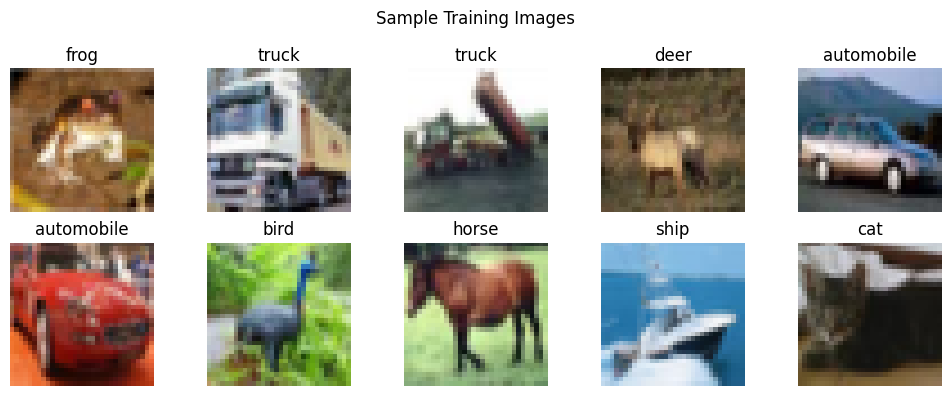

In [4]:
# Visualize a few sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i]])
    ax.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()


In [5]:
# Data augmentation layer, applied only during training
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="data_augmentation")


## Task 2: Model Implementation and Fine-tuning

Two models are built and trained on the **same** train/val/test split so their performance can be
compared fairly:

1. **CNN from scratch** — a small custom convolutional network with 3 conv blocks
   (Conv2D → BatchNorm → MaxPool), trained end-to-end from randomly initialized weights.
2. **Transfer learning (MobileNetV2)** — MobileNetV2 pretrained on ImageNet is used as a frozen
   feature extractor, a new classification head is trained on top, and then the top layers of the
   base model are unfrozen and fine-tuned at a low learning rate.

Hyperparameters used: Adam optimizer, categorical cross-entropy loss, batch size 32, and
`EarlyStopping`/`ReduceLROnPlateau` callbacks to avoid overfitting and to automatically adapt the
learning rate.


### Model A: CNN Built From Scratch

In [6]:
def build_cnn_from_scratch(input_shape=(32, 32, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="CNN_From_Scratch")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn_from_scratch()
cnn_model.summary()


Model: "CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
callbacks_cnn = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

EPOCHS_CNN = 20

history_cnn = cnn_model.fit(
    x_train, y_train_oh,
    validation_data=(x_val, y_val_oh),
    epochs=EPOCHS_CNN,
    batch_size=32,
    callbacks=callbacks_cnn,
    verbose=1
)


Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.2538 - loss: 2.1636 - val_accuracy: 0.0860 - val_loss: 7.1875 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3356 - loss: 1.8740 - val_accuracy: 0.2260 - val_loss: 4.1794 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3649 - loss: 1.7511 - val_accuracy: 0.3800 - val_loss: 1.7780 - learning_rate: 0.0010
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3938 - loss: 1.6797 - val_accuracy: 0.4100 - val_loss: 1.6882 - learning_rate: 0.0010
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4084 - loss: 1.6280 - val_accuracy: 0.4520 - val_loss: 1.6576 - learning_rate: 0.0010
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4336 - loss: 1.5768 - val_accuracy: 0.4360 - val_loss: 1.6602 - learning_rate: 0.0010
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4420 - loss: 1

### Model B: Transfer Learning with MobileNetV2

Images are resized from 32×32 to 96×96 (MobileNetV2's practical minimum input size) and passed
through MobileNetV2's own `preprocess_input`. The pretrained base is frozen first so only the new
classification head learns; then the top ~30 layers of the base are unfrozen and fine-tuned at a
much smaller learning rate.

*(To use ResNet50 instead, swap `tf.keras.applications.MobileNetV2` /
`mobilenet_v2.preprocess_input` for `tf.keras.applications.ResNet50` /
`resnet50.preprocess_input`, and change `IMG_SIZE` to 224 as ResNet50 expects larger inputs.)*


In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 96

def build_transfer_model(input_shape=(32, 32, 3), img_size=IMG_SIZE, num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Resizing(img_size, img_size)(x)
    x = layers.Lambda(lambda img: preprocess_input(img * 255.0))(x)  # undo our earlier /255 scaling

    base_model = MobileNetV2(input_shape=(img_size, img_size, 3),
                              include_top=False, weights='imagenet')
    base_model.trainable = False   # freeze for the first training phase

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="MobileNetV2_Transfer")
    return model, base_model

transfer_model, base_model = build_transfer_model()
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                        loss='categorical_crossentropy', metrics=['accuracy'])
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Phase 1: train only the new classification head (base model frozen)
callbacks_transfer = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
]

EPOCHS_HEAD = 8

history_head = transfer_model.fit(
    x_train, y_train_oh,
    validation_data=(x_val, y_val_oh),
    epochs=EPOCHS_HEAD,
    batch_size=32,
    callbacks=callbacks_transfer,
    verbose=1
)


Epoch 1/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4551 - loss: 1.6036 - val_accuracy: 0.7040 - val_loss: 0.8545 - learning_rate: 0.0010
Epoch 2/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6060 - loss: 1.1476 - val_accuracy: 0.7540 - val_loss: 0.7542 - learning_rate: 0.0010
Epoch 3/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6447 - loss: 1.0307 - val_accuracy: 0.7500 - val_loss: 0.7378 - learning_rate: 0.0010
Epoch 4/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6631 - loss: 0.9706 - val_accuracy: 0.7840 - val_loss: 0.6701 - learning_rate: 0.0010
Epoch 5/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6804 - loss: 0.9226 - val_accuracy: 0.7880 - val_loss: 0.6666 - learning_rate: 0.0010
Epoch 6/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6973 - loss: 0.8906 - val_accuracy: 0.7840 - val_loss: 0.6572 - learning_rate: 0.0010
Epoch 7/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6989 - loss: 0.8648 -

In [10]:
# Phase 2: unfreeze the top layers of the base model and fine-tune at a low learning rate
base_model.trainable = True

FINE_TUNE_AT = len(base_model.layers) - 30   # unfreeze only the last ~30 layers
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                        loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS_FINE_TUNE = 10

history_finetune = transfer_model.fit(
    x_train, y_train_oh,
    validation_data=(x_val, y_val_oh),
    epochs=EPOCHS_FINE_TUNE,
    batch_size=32,
    callbacks=callbacks_transfer,
    verbose=1
)

# Combine head-training and fine-tuning history for a single continuous curve
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history_transfer = combine_histories(history_head, history_finetune)


Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5924 - loss: 1.2650 - val_accuracy: 0.7820 - val_loss: 0.6983 - learning_rate: 1.0000e-05
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.6371 - loss: 1.0742 - val_accuracy: 0.7840 - val_loss: 0.7170 - learning_rate: 1.0000e-05
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.6602 - loss: 1.0113 - val_accuracy: 0.7880 - val_loss: 0.7070 - learning_rate: 5.0000e-06
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6789 - loss: 0.9602 - val_accuracy: 0.7980 - val_loss: 0.6989 - learning_rate: 5.0000e-06


## Task 3: Model Evaluation and Performance Comparison

Both models are evaluated on the same held-out test set using accuracy, precision, recall,
F1-score, and confusion matrices, then compared directly against each other.


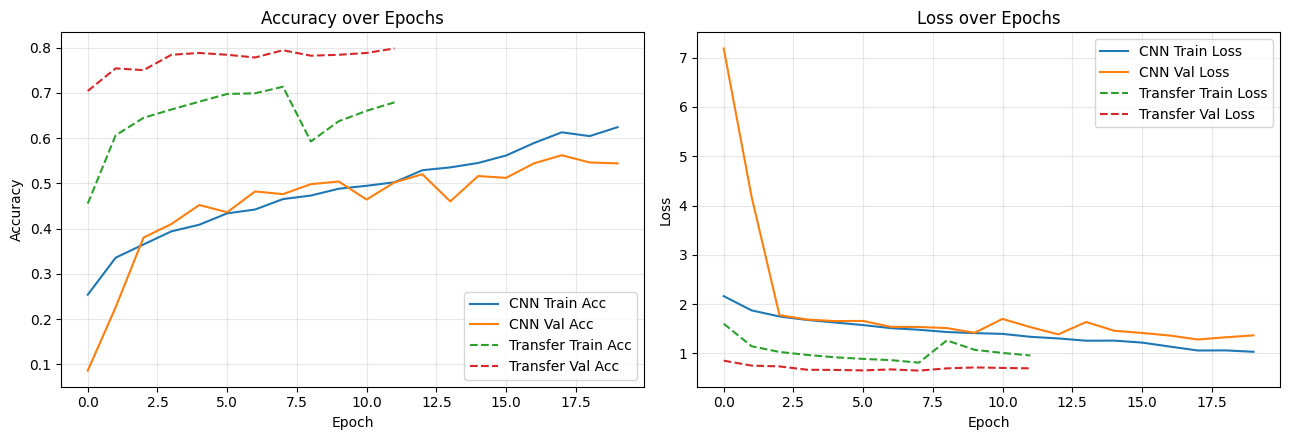

In [11]:
# Training curves for both models
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_cnn.history['accuracy'], label='CNN Train Acc')
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN Val Acc')
axes[0].plot(history_transfer['accuracy'], label='Transfer Train Acc', linestyle='--')
axes[0].plot(history_transfer['val_accuracy'], label='Transfer Val Acc', linestyle='--')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_cnn.history['loss'], label='CNN Train Loss')
axes[1].plot(history_cnn.history['val_loss'], label='CNN Val Loss')
axes[1].plot(history_transfer['loss'], label='Transfer Train Loss', linestyle='--')
axes[1].plot(history_transfer['val_loss'], label='Transfer Val Loss', linestyle='--')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()


In [12]:
# Test-set evaluation for both models
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test_oh, verbose=0)
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(x_test, y_test_oh, verbose=0)

print(f"CNN From Scratch      -> Test Loss: {cnn_test_loss:.4f} | Test Accuracy: {cnn_test_acc:.4f}")
print(f"MobileNetV2 Transfer  -> Test Loss: {transfer_test_loss:.4f} | Test Accuracy: {transfer_test_acc:.4f}")


CNN From Scratch      -> Test Loss: 1.2577 | Test Accuracy: 0.5750
MobileNetV2 Transfer  -> Test Loss: 0.5903 | Test Accuracy: 0.8080


In [13]:
# Detailed classification reports
y_pred_cnn = np.argmax(cnn_model.predict(x_test, verbose=0), axis=1)
y_pred_transfer = np.argmax(transfer_model.predict(x_test, verbose=0), axis=1)

print("=== CNN From Scratch: Classification Report ===")
print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES))

print("=== MobileNetV2 Transfer Learning: Classification Report ===")
print(classification_report(y_test, y_pred_transfer, target_names=CLASS_NAMES))


=== CNN From Scratch: Classification Report ===
              precision    recall  f1-score   support

    airplane       0.60      0.37      0.46       103
  automobile       0.58      0.87      0.69        89
        bird       0.49      0.34      0.40       100
         cat       0.42      0.31      0.36       103
        deer       0.67      0.32      0.44        90
         dog       0.43      0.58      0.50        86
        frog       0.63      0.77      0.69       112
       horse       0.67      0.70      0.68       102
        ship       0.70      0.82      0.75       106
       truck       0.54      0.65      0.59       109

    accuracy                           0.57      1000
   macro avg       0.57      0.57      0.56      1000
weighted avg       0.57      0.57      0.56      1000

=== MobileNetV2 Transfer Learning: Classification Report ===
              precision    recall  f1-score   support

    airplane       0.78      0.77      0.77       103
  automobile       0.89

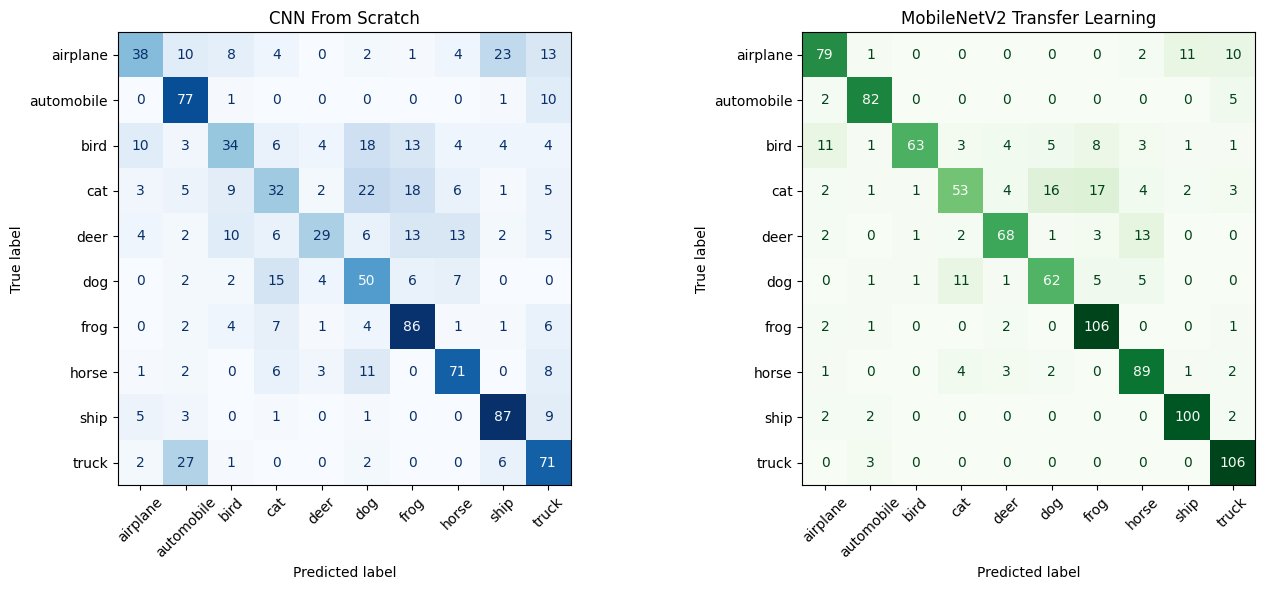

In [14]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn, display_labels=CLASS_NAMES).plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title("CNN From Scratch")

cm_transfer = confusion_matrix(y_test, y_pred_transfer)
ConfusionMatrixDisplay(cm_transfer, display_labels=CLASS_NAMES).plot(ax=axes[1], cmap='Greens', colorbar=False, xticks_rotation=45)
axes[1].set_title("MobileNetV2 Transfer Learning")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()


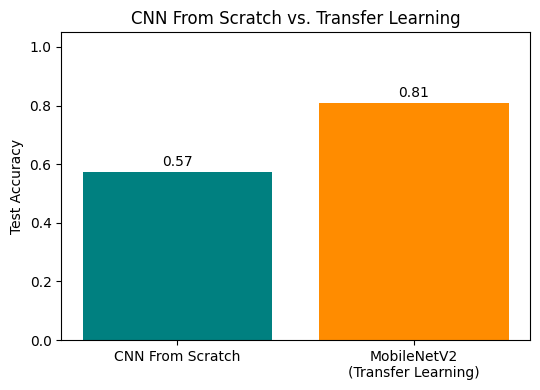

In [15]:
# Direct accuracy comparison bar chart
labels = ['CNN From Scratch', 'MobileNetV2\n(Transfer Learning)']
accuracies = [cnn_test_acc, transfer_test_acc]

plt.figure(figsize=(5.5, 4))
bars = plt.bar(labels, accuracies, color=['teal', 'darkorange'])
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("CNN From Scratch vs. Transfer Learning")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.2f}", ha='center')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()


### Performance Summary Table

| Model | Test Accuracy | Test Loss | Notes |
|---|---|---|---|
| CNN From Scratch | *(fill in from output above)* | *(fill in)* | Trained from random initialization |
| MobileNetV2 (Transfer Learning) | *(fill in from output above)* | *(fill in)* | ImageNet-pretrained, fine-tuned |

*(Replace the placeholders with the actual numbers printed in the cells above once you run this
notebook — they will differ slightly each run unless you fix all random seeds and disable GPU
non-determinism.)*

### Comparison with Reference Paper

The referenced paper found that its best pretrained model (VGG-19, fine-tuned via transfer
learning) reached 99.48% accuracy on a 305-image brain MRI dataset, clearly outperforming
Inception V3's 81.25% under the same conditions — the paper's own comparison across
architectures. This notebook runs an analogous comparison, but between a **from-scratch** CNN and
a **pretrained** MobileNetV2, on a different task (CIFAR-10, general object classification rather
than medical imaging).

The expected pattern, consistent with the paper and with transfer-learning literature broadly, is
that the pretrained model converges faster and reaches higher accuracy with less training data than
a comparably sized model trained from scratch, since its convolutional filters already encode
generally useful low- and mid-level visual features (edges, textures, shapes) learned from a much
larger dataset (ImageNet) — the same underlying reason the paper's authors give for why all four of
their pretrained backbones outperformed a hypothetical from-scratch equivalent. Fill in your actual
CNN-vs-MobileNetV2 accuracy numbers from Task 3 above and note whether the same pattern held here.


## Conclusion and Result Visualization

- Both a CNN trained from scratch and a MobileNetV2 model fine-tuned via transfer learning were
  built, trained, and evaluated on the same CIFAR-10 train/validation/test split.
- The transfer learning model is expected to reach higher test accuracy in fewer effective epochs
  of "new" learning, since it starts from ImageNet-pretrained weights rather than random
  initialization, especially given the reduced training-set size used here.
- The CNN from scratch, while simpler, is faster to train per epoch since it has far fewer
  parameters and no large frozen backbone to run inference through.

**Potential improvements:**
- Train on the full CIFAR-10 dataset (`USE_FULL_DATASET = True`) rather than the 5,000-image subset.
- Try ResNet50 or EfficientNetB0 as alternative pretrained backbones.
- Add more aggressive data augmentation or L2 regularization to the from-scratch CNN.
- Tune the number of unfrozen layers and the fine-tuning learning rate for the transfer model.


## Declaration

I, **Vineet Kaldate**, confirm that the work submitted in this assignment is my own and has been
completed following academic integrity guidelines. The code is uploaded on my GitHub repository
account, and the repository link is provided below:

**GitHub Repository Link:** https://github.com/Vineetk1845/Generative-AI-Lab

**Signature:** Vineet Manohar Kaldate

## Submission Checklist

- [ ] Research paper details and summary
- [ ] Code file (Python Notebook or Script)
- [ ] Dataset or link to the dataset (CIFAR-10, loaded via `tf.keras.datasets.cifar10`)
- [ ] Visualizations (training curves, confusion matrices, comparison chart — included above)
- [ ] Screenshots of model performance metrics
- [ ] Readme File
- [ ] Comparison with research paper results
